## Question 2

**Perform Multiple Linear Regression (MLR) to predict house prices using the following dataset:**

| Size (sq ft) | Number of Rooms | Price (in lakhs) |
|--------------|----------------|------------------|
| 800          | 2              | 40               |
| 1000         | 3              | 55               |
| 1200         | 3              | 65               |
| 1500         | 4              | 80               |
| 1800         | 4              | 95               |

### Tasks

1. **Perform MLR using Gradient Descent**
2. **Perform MLR using Closed-Form Solution (Normal Equation)**
3. **Perform MLR using an Iterative Method (Feature Scaling + Gradient Descent)**
4. **Verify the results using the sklearn package**

In [2]:
#To get the house prediction function as a linear model we get Price = b0 + b1*Size + b2*Rooms 

<font size = 5 color = 'red'>Gradient Descent Method</font>
<image src='image1.png'></image>
<image src = 'image2.png'></image>

In [3]:
import numpy as np
X = np.array([[800, 2],[1000, 3],[1200, 3],[1500, 4],[1800, 4]])
y = np.array([40, 55, 65, 80, 95]).reshape(-1, 1) #.shape (5, 1) 
X_b = np.c_[np.ones((X.shape[0], 1)), X]
#now X_b is (5, 3) with bias term , we need bias term for b0

theta = np.zeros((3, 1))
alpha = 1e-7
iterations = 100000

# Gradient Descent
for _ in range(iterations):
    gradients = (2 / len(X_b)) * X_b.T.dot(X_b.dot(theta) - y)
    #gradients.shape (3, 1)
    theta = theta - alpha * gradients

print("Gradient Descent Coefficients:")
print(theta[0], theta[1], theta[2])  # b0, b1, b2

Gradient Descent Coefficients:
[-0.00082679] [0.05319587] [0.00544786]


<font size = 5 color = 'orange'>Closed-Form Solution</font>
<image src = 'image3.png'></image>

In [4]:
# Normal Equation
theta_closed = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Closed Form Coefficients:")
print(theta_closed[0,], theta_closed[1], theta_closed[2])  # b0, b1, b2


Closed Form Coefficients:
[-3.53448276] [0.04568966] [4.05172414]


<font size = 5 color = 'lightgreen'>Iterative Method</font>

In [5]:
# Feature Scaling
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
X_scaled_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

theta_iter = np.zeros((3, 1))
alpha = 0.1
iterations = 5000

for _ in range(iterations):
    gradients = (2 / len(X_scaled_b)) * X_scaled_b.T.dot(
        X_scaled_b.dot(theta_iter) - y
    )
    theta_iter = theta_iter - alpha * gradients

print("Iterative Method Coefficients:")
print(theta_iter[0], theta_iter[1], theta_iter[2])  # b0, b1, b2


Iterative Method Coefficients:
[67.] [16.24394152] [3.03203271]


<font size = 5 color = 'yellow'>Verification with Sklearn</font>

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Sklearn Intercept:", model.intercept_)
print("Sklearn Coefficients:", model.coef_)
print("Sklearn Coefficients (b0, b1, b2): {:.4f} {:.4f} {:.4f}".format(model.intercept_[0], model.coef_[0][0], model.coef_[0][1]))

Sklearn Intercept: [-3.53448276]
Sklearn Coefficients: [[0.04568966 4.05172414]]
Sklearn Coefficients (b0, b1, b2): -3.5345 0.0457 4.0517


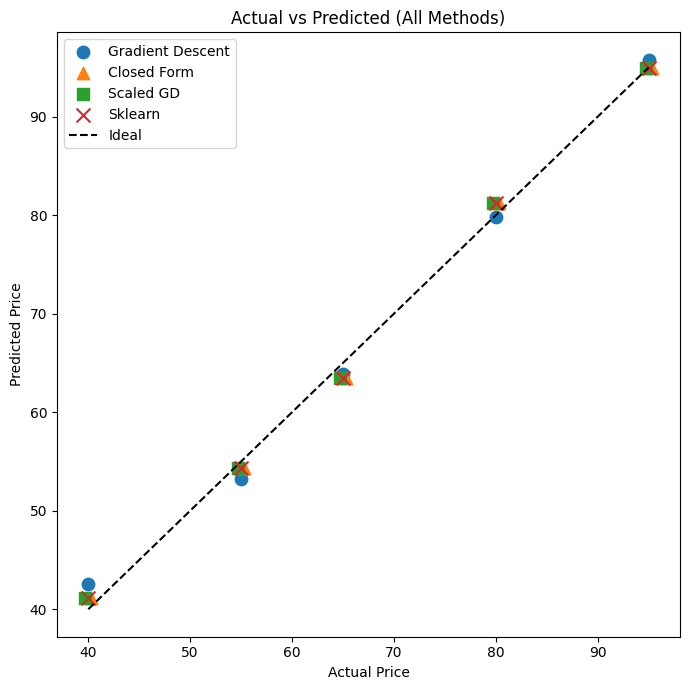

In [8]:
import matplotlib.pyplot as plt

# Predictions from each method
y_pred_gd = X_b.dot(theta)                 # Gradient Descent
y_pred_closed = X_b.dot(theta_closed)      # Normal Equation

# For scaled GD, we must use scaled X
y_pred_iter = X_scaled_b.dot(theta_iter)   # Scaled Gradient Descent

# Sklearn predictions
y_pred_sklearn = model.predict(X)

# Plot
plt.figure(figsize=(7, 7))

plt.scatter(y, y_pred_gd, marker='o', s=80, label="Gradient Descent")
plt.scatter(y + 0.3, y_pred_closed, marker='^', s=80, label="Closed Form")
plt.scatter(y - 0.3, y_pred_iter, marker='s', s=80, label="Scaled GD")
plt.scatter(y, y_pred_sklearn, marker='x', s=100, label="Sklearn")


# Ideal line
min_y, max_y = y.min(), y.max()
plt.plot([min_y, max_y], [min_y, max_y], 'k--', label="Ideal")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (All Methods)")
plt.legend()
plt.tight_layout()
plt.show()


$$
\text{Price} = -3.5345 + (0.0457 \times \text{SqFt}) + (4.0517 \times \text{Bedrooms})
$$